# Lung Cancer Regression Model

In [23]:
import os
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsRegressor

In [2]:
path = os.getcwd()

In [3]:
Lung_Data = pd.read_csv(f"{path}\Lung_Cancer_Trends_Realistic.csv")

<>:1: SyntaxWarning: invalid escape sequence '\L'
<>:1: SyntaxWarning: invalid escape sequence '\L'
C:\Users\Data Analyst\AppData\Local\Temp\ipykernel_11880\1131841498.py:1: SyntaxWarning: invalid escape sequence '\L'
  Lung_Data = pd.read_csv(f"{path}\Lung_Cancer_Trends_Realistic.csv")


In [4]:
Lung_Data.head()

,Patient_ID,Age,Gender,Smoking_Status,Years_Smoking,Cigarettes_Per_Day,Secondhand_Smoke_Exposure,Occupation_Exposure,Air_Pollution_Level,Family_History,...,Diet_Quality,Region,Income_Level,Education_Level,Access_to_Healthcare,Screening_Frequency,Chronic_Lung_Disease,Lung_Cancer_Stage,Diagnosis_Year,Survival_Status
0,P100000,76,Female,Never,6,37,Low,Diesel Fumes,Low,Yes,...,Poor,West,Middle,Tertiary,Good,Regularly,No,Stage II,2008,Alive
1,P100001,39,Male,Never,30,39,Low,Silica,Low,Yes,...,Average,North,Middle,Primary,Poor,Occasionally,Yes,NaN,2002,Alive
2,P100002,85,Male,Former,47,14,High,Asbestos,Low,Yes,...,Good,South,High,Tertiary,Average,Regularly,No,Stage II,2007,Deceased
3,P100003,45,Female,Current,45,32,Medium,Silica,High,No,...,Good,West,Low,Secondary,Average,Never,Yes,NaN,2011,Alive
4,P100004,48,Female,Never,46,26,Medium,Silica,Low,No,...,Good,North,Low,Tertiary,Average,Regularly,No,NaN,2016,Alive


In [5]:
Lung_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Patient_ID                 3000 non-null   object 
 1   Age                        3000 non-null   int64  
 2   Gender                     3000 non-null   object 
 3   Smoking_Status             3000 non-null   object 
 4   Years_Smoking              3000 non-null   int64  
 5   Cigarettes_Per_Day         3000 non-null   int64  
 6   Secondhand_Smoke_Exposure  3000 non-null   object 
 7   Occupation_Exposure        2256 non-null   object 
 8   Air_Pollution_Level        3000 non-null   object 
 9   Family_History             3000 non-null   object 
 10  Genetic_Markers_Positive   3000 non-null   object 
 11  BMI                        3000 non-null   float64
 12  Physical_Activity_Level    3000 non-null   object 
 13  Alcohol_Consumption        2025 non-null   objec

In [6]:
Lung_Data = pd.DataFrame(Lung_Data)

In [7]:
print('String columns' ,Lung_Data.select_dtypes(include=['int64','float64']).columns)

String columns Index(['Age', 'Years_Smoking', 'Cigarettes_Per_Day', 'BMI', 'Diagnosis_Year'], dtype='object')


In [8]:
print('String columns' ,Lung_Data.select_dtypes(include='object').columns)

String columns Index(['Patient_ID', 'Gender', 'Smoking_Status', 'Secondhand_Smoke_Exposure',
       'Occupation_Exposure', 'Air_Pollution_Level', 'Family_History',
       'Genetic_Markers_Positive', 'Physical_Activity_Level',
       'Alcohol_Consumption', 'Diet_Quality', 'Region', 'Income_Level',
       'Education_Level', 'Access_to_Healthcare', 'Screening_Frequency',
       'Chronic_Lung_Disease', 'Lung_Cancer_Stage', 'Survival_Status'],
      dtype='object')


In [9]:
strings= Lung_Data[['Patient_ID', 'Gender', 'Smoking_Status', 'Secondhand_Smoke_Exposure',
       'Occupation_Exposure', 'Air_Pollution_Level', 'Family_History',
       'Genetic_Markers_Positive', 'Physical_Activity_Level',
       'Alcohol_Consumption', 'Diet_Quality', 'Region', 'Income_Level',
       'Education_Level', 'Access_to_Healthcare', 'Screening_Frequency',
       'Chronic_Lung_Disease', 'Lung_Cancer_Stage', 'Survival_Status']]

strings = pd.DataFrame(strings)

In [10]:
for column in strings:
    Encode = LabelEncoder()
    Lung_Data[column] = Encode.fit_transform(Lung_Data[column])
    print(f"{column} Unique values after conversion= {Lung_Data[column].unique()}")
   

Patient_ID Unique values after conversion= [   0    1    2 ... 2997 2998 2999]
Gender Unique values after conversion= [0 1]
Smoking_Status Unique values after conversion= [2 1 0]
Secondhand_Smoke_Exposure Unique values after conversion= [1 0 2]
Occupation_Exposure Unique values after conversion= [1 2 0 3]
Air_Pollution_Level Unique values after conversion= [1 0 2]
Family_History Unique values after conversion= [1 0]
Genetic_Markers_Positive Unique values after conversion= [0 1]
Physical_Activity_Level Unique values after conversion= [2 0 1]
Alcohol_Consumption Unique values after conversion= [1 0 2]
Diet_Quality Unique values after conversion= [2 0 1]
Region Unique values after conversion= [3 1 2 0]
Income_Level Unique values after conversion= [2 0 1]
Education_Level Unique values after conversion= [2 0 1]
Access_to_Healthcare Unique values after conversion= [1 2 0]
Screening_Frequency Unique values after conversion= [2 1 0]
Chronic_Lung_Disease Unique values after conversion= [0 1]
Lu

In [11]:
Lung_Data.drop(['Patient_ID','Education_Level','Income_Level','Diagnosis_Year'], axis= 1)

,Age,Gender,Smoking_Status,Years_Smoking,Cigarettes_Per_Day,Secondhand_Smoke_Exposure,Occupation_Exposure,Air_Pollution_Level,Family_History,Genetic_Markers_Positive,BMI,Physical_Activity_Level,Alcohol_Consumption,Diet_Quality,Region,Access_to_Healthcare,Screening_Frequency,Chronic_Lung_Disease,Lung_Cancer_Stage,Survival_Status
0,76,0,2,6,37,1,1,1,1,0,24.6,2,1,2,3,1,2,0,1,0
1,39,1,2,30,39,1,2,1,1,0,17.5,2,1,0,1,2,1,1,4,0
2,85,1,1,47,14,0,0,1,1,1,33.6,0,0,1,2,0,2,0,1,1
3,45,0,0,45,32,2,2,0,0,0,23.2,2,1,1,3,0,0,1,4,0
4,48,0,2,46,26,2,2,1,0,1,22.9,0,0,1,1,0,2,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,39,1,0,15,27,1,2,0,0,0,10.7,0,2,0,0,2,2,0,4,0
2996,61,1,1,5,13,0,2,2,1,0,22.0,2,2,1,0,2,1,0,2,1
2997,25,1,2,6,33,0,2,0,1,1,18.2,0,0,2,0,2,0,0,3,0
2998,48,1,0,49,10,2,3,1,1,0,20.4,1,1,0,3,0,1,0,4,0


In [12]:
Lung_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Patient_ID                 3000 non-null   int64  
 1   Age                        3000 non-null   int64  
 2   Gender                     3000 non-null   int64  
 3   Smoking_Status             3000 non-null   int64  
 4   Years_Smoking              3000 non-null   int64  
 5   Cigarettes_Per_Day         3000 non-null   int64  
 6   Secondhand_Smoke_Exposure  3000 non-null   int64  
 7   Occupation_Exposure        3000 non-null   int64  
 8   Air_Pollution_Level        3000 non-null   int64  
 9   Family_History             3000 non-null   int64  
 10  Genetic_Markers_Positive   3000 non-null   int64  
 11  BMI                        3000 non-null   float64
 12  Physical_Activity_Level    3000 non-null   int64  
 13  Alcohol_Consumption        3000 non-null   int64

In [49]:
Lung_Data['Lung_Cancer_Stage'].value_counts()

Lung_Cancer_Stage
4    2402
0     155
2     150
3     147
1     146
Name: count, dtype: int64

Data is skewed with s large number of values consisting of Lung Cancer stage of value (4)

In [ ]:
# Reduce the amount 
Lung_Data[Lung_Data['Lung_Cancer_Stage'] == 4]

to_drop = Lung_Data.sample(n=2250)
droped = Lung_Data.drop(to_drop)
droped

,Patient_ID,Age,Gender,Smoking_Status,Years_Smoking,Cigarettes_Per_Day,Secondhand_Smoke_Exposure,Occupation_Exposure,Air_Pollution_Level,Family_History,...,Diet_Quality,Region,Income_Level,Education_Level,Access_to_Healthcare,Screening_Frequency,Chronic_Lung_Disease,Lung_Cancer_Stage,Diagnosis_Year,Survival_Status
1,1,39,1,2,30,39,1,2,1,1,...,0,1,2,0,2,1,1,4,2002,0
3,3,45,0,0,45,32,2,2,0,0,...,1,3,1,1,0,0,1,4,2011,0
4,4,48,0,2,46,26,2,2,1,0,...,1,1,1,2,0,2,0,4,2016,0
5,5,27,1,0,13,28,1,2,0,0,...,2,0,2,2,0,2,0,4,2013,0
8,8,26,0,2,15,28,2,2,1,0,...,2,2,2,2,2,0,0,4,2003,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2992,2992,43,0,2,2,35,0,0,2,0,...,1,0,0,1,1,0,0,4,2009,0
2993,2993,70,0,0,26,34,0,1,1,1,...,2,0,2,1,1,2,0,4,2015,0
2994,2994,52,1,1,16,16,1,0,1,1,...,1,1,0,2,2,2,0,4,2021,0
2995,2995,39,1,0,15,27,1,2,0,0,...,0,0,2,0,2,2,0,4,2022,0


In [13]:
X = Lung_Data.drop(['Lung_Cancer_Stage'], axis=1)
Y = Lung_Data['Lung_Cancer_Stage']

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2 , random_state=50)

In [15]:
print(Y_train.shape)

(2400,)


In [16]:
scale = StandardScaler()
X_train_scale = scale.fit_transform(X_train)
X_test_scale = scale.fit_transform(X_test)

In [17]:
ln = LinearRegression()
ln.fit(X_train, Y_train)
pre = ln.predict(X_test)
print(f"Accuracy Result = {accuracy_score(Y_test,pre.round())}")
print(f"Clasification Report:")
print(classification_report(Y_test,pre.round()))

Accuracy Result = 0.4633333333333333
Clasification Report:


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        32
           1       0.00      0.00      0.00        37
           2       0.00      0.00      0.00        29
           3       0.06      0.56      0.10        27
           4       0.79      0.55      0.65       475

    accuracy                           0.46       600
   macro avg       0.17      0.22      0.15       600
weighted avg       0.62      0.46      0.52       600



C:\Users\Data Analyst\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Data Analyst\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Data Analyst\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

In [18]:
Kn = KNeighborsRegressor()
Kn.fit(X_train, Y_train)
pre = ln.predict(X_test)
print(f"Accuracy Result = {accuracy_score(Y_test,pre.round())}")
print(f"Clasification Report:")
print(classification_report(Y_test,pre.round()))

Accuracy Result = 0.4633333333333333
Clasification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        32
           1       0.00      0.00      0.00        37
           2       0.00      0.00      0.00        29
           3       0.06      0.56      0.10        27
           4       0.79      0.55      0.65       475

    accuracy                           0.46       600
   macro avg       0.17      0.22      0.15       600
weighted avg       0.62      0.46      0.52       600



C:\Users\Data Analyst\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Data Analyst\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Data Analyst\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

C:\Users\Data Analyst\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Data Analyst\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Data Analyst\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

<function matplotlib.pyplot.show(close=None, block=None)>

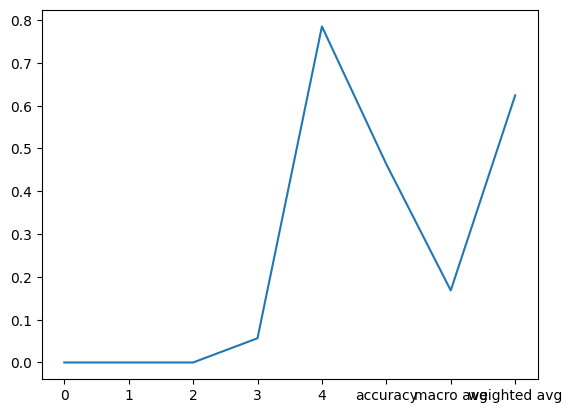

In [40]:
rep = classification_report(Y_test,pre.round(), output_dict = True)

rep = pd.DataFrame(rep).transpose()
plt.plot(rep['precision'])
plt.show